this is NOT trained on lola - aug 17

In [322]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import griddata
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [323]:
df = pd.read_csv('..\\data\\lola_grav_age_q_z_bath.csv')
df.head()

,long,lat,FA,age,q_ihfc,q_ps,q_stein,ps_z,stein_z,bathy
0,-133.000003,37.983334,-20.522749,33.939312,19.0,81.209931,87.542442,4539.010966,423035.068147,-5025.0
1,-133.000003,38.100001,-24.824638,33.939312,19.0,81.209931,87.542442,4539.010966,423035.068147,-5037.0
2,-133.000003,38.216667,-31.192137,33.939312,19.0,81.209931,87.542442,4539.010966,423035.068147,-5054.0
3,-133.000003,38.333334,-38.186611,33.939312,19.0,81.209931,87.542442,4539.010966,423035.068147,-5046.0
4,-133.000003,38.450001,-32.169643,33.939312,19.0,81.209931,87.542442,4539.010966,423035.068147,-4910.0


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [324]:
x = df.drop(columns=['long', 'lat', 'q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [325]:
x.head()

,age,q_ihfc,bathy
0,33.939312,19.0,-5025.0
1,33.939312,19.0,-5037.0
2,33.939312,19.0,-5054.0
3,33.939312,19.0,-5046.0
4,33.939312,19.0,-4910.0


In [326]:
x.shape

(16698, 3)

In [327]:
y.head()

0   -20.522749
1   -24.824638
2   -31.192137
3   -38.186611
4   -32.169643
Name: FA, dtype: float64

In [328]:
ts = 0.2
rs = 17

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts, random_state = rs)

this is just for plotting, but ensures that lat/long isnt a dependency

In [329]:
coords_train = df.loc[x_train.index, ['long', 'lat']]
coords_test = df.loc[x_test.index, ['long', 'lat']]

In [330]:
x_train.shape

(13358, 3)

this is the raw validation data

In [331]:
x_test.shape

(3340, 3)

In [332]:
x_train.describe().round(3)

,age,q_ihfc,bathy
count,13358.000,13358.000,13358.000
mean,9.364,236.965,-1018.945
std,7.204,692.149,2084.234
min,0.034,6.946,-5054.000
25%,4.993,47.714,-2946.400
50%,8.299,72.246,-142.401
75%,9.732,111.435,929.000
max,35.200,6806.313,3135.232


In [333]:
x_test.describe().round(3)

,age,q_ihfc,bathy
count,3340.000,3340.000,3340.000
mean,9.204,244.198,-1021.304
std,7.066,689.407,2055.021
min,0.079,8.000,-5056.999
25%,4.857,48.204,-2926.325
50%,8.225,72.934,-139.851
75%,9.726,113.965,904.576
max,34.939,6343.173,2401.519


In [334]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

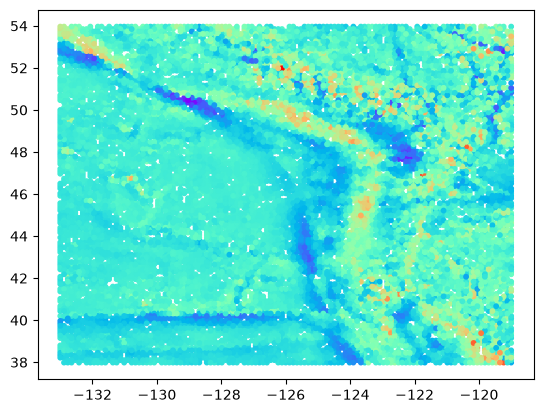

In [335]:
plt.scatter(coords_train['long'], coords_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

# plt.savefig('..\\figs\\grav\\aug17_trainpnts.png', dpi=400)
plt.show()

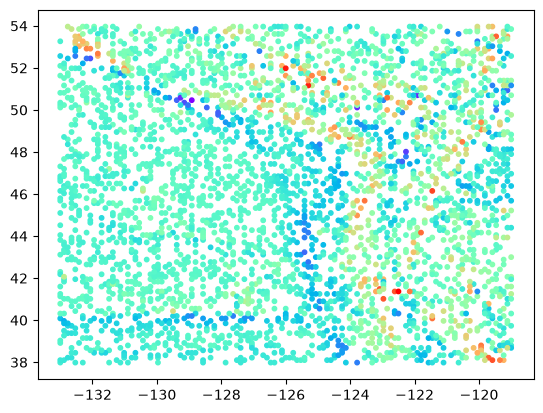

In [336]:
plt.scatter(coords_test['long'], coords_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

# plt.savefig('..\\figs\\grav\\aug17_testpnts.png', dpi=400)
plt.show()

'min_data_in_leaf': 20,  # default 20 — lower allows smaller/more specific splits, higher = more conservative

In [337]:
lr = 0.1
nl = 33
mdil = 20

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'num_leaves':nl,
    'min_data_in_leaf': mdil,
    'verbose':1
}

testing nbr and lr, 500 has R^2 of 0.69 as of aug 14 2:59 pm

nbr is total number of trees build in the model

In [338]:
nbr = 500
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 13358, number of used features: 3
[LightGBM] [Info] Start training from score -3.604600


In [339]:
y_pred = model.predict(x_test)

In [340]:
y_pred, y_pred.shape

(array([ 28.8890085 ,  -8.94491702,  -6.18278768, ...,  16.90518505,
        -18.13810571,  36.91830412], shape=(3340,)),
 (3340,))

In [341]:
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')

RMSE: 23.517929083687243
R^2: 0.5188997481752581


In [342]:
residuals = y_test - y_pred

negative mean: overpredicting

In [343]:
residuals.head(), residuals.describe()

(14198   -23.285012
 3497     -1.773905
 7245     -0.804422
 7111      2.044018
 12208   -10.934108
 Name: FA, dtype: float64,
 count    3340.000000
 mean        0.012237
 std        23.521447
 min      -112.862493
 25%        -9.455565
 50%        -0.037022
 75%         8.947313
 max       108.921261
 Name: FA, dtype: float64)

In [344]:
# dfr = pd.DataFrame({
#     'long': x_test['long'].values,
#     'lat': x_test['lat'].values,
#     'ps_q_test_data': y_test,
#     'ps_q_predicted': y_pred,
#     'residual': residuals
# })

saving both the csv file and a text file of specified parameters

In [345]:
# pd.DataFrame(dfr).to_csv('..\\created_data\\tests\\aug17_grav_residuals.csv', index=False)

with open('..\\created_data\\tests\\aug17_NOlola_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\nnum leaves: {nl}\nmin data in leaf: {mdil}\n')
    # f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'\ndescription:\n{residuals.describe()}\n')
    f.write(f'RMSE: {root_mean_squared_error(y_test, y_pred)}\n')
    f.write(f'R^2: {r2_score(y_test, y_pred)}\n')
    f.write(f'\nnote: this was for random state {rs}')
    f.write(f'\n- model is NOT trained on lat/long; with grav data correlation')

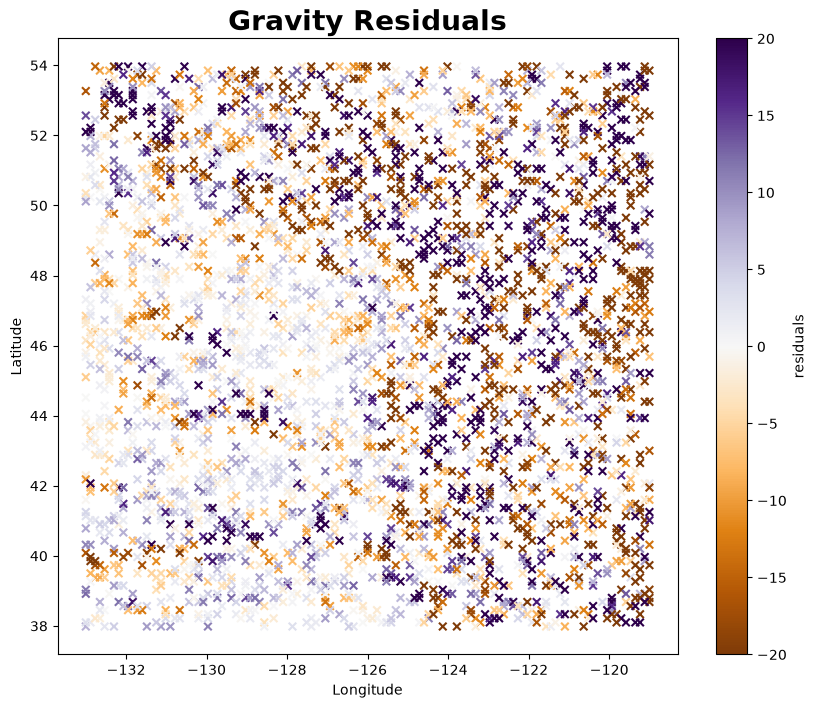

In [346]:
plt.figure(figsize=(10, 8))
plt.scatter(coords_test['long'], coords_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-20, vmax=20)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\aug17_NOlola_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

we start with just predicting the same area on an empty grid

In [347]:
sp = 250
grid_long = np.linspace(coords_test['long'].min(), coords_test['long'].max(), sp)
grid_lat = np.linspace(coords_test['lat'].min(), coords_test['lat'].max(), sp)

In [348]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [349]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [350]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [351]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 249, 249, 249], shape=(62500,)),
 array([  0,   1,   2, ..., 247, 248, 249], shape=(62500,)))

In [352]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[88.94621478, 84.37803385, 82.55182973, 80.47358668, 78.48304436],
        [88.60453242, 85.22955057, 83.12938235, 81.0511393 , 79.06059698],
        [90.52414739, 89.36493617, 83.79371138, 81.62869193, 79.6381496 ],
        [93.36872491, 92.73882788, 87.06133284, 82.20624455, 80.21570222],
        [94.44097588, 94.63992825, 87.90939157, 82.78379717, 80.79325484]]),
 array([[8.01074131, 8.13340656, 8.23683734, 8.33887256, 8.40218859],
        [8.02202001, 8.14360998, 8.255325  , 8.35736022, 8.42067625],
        [8.02318118, 8.13600011, 8.27317613, 8.37584788, 8.43916391],
        [8.02019828, 8.13342999, 8.27193151, 8.39433554, 8.45765157],
        [8.02566025, 8.13540925, 8.28704519, 8.4128232 , 8.47613923]]),
 array([[-2390.770599  , -2262.37695874, -2218.49781211, -2066.85436769,
         -1920.37439771],
        [-2384.73610304, -2308.16065465, -2154.18872181, -2013.47073508,
         -1851.98518636],
        [-2288.4736622 , -2261.26467987, -2279.71673311, -2147.19268006,


In [353]:
age_interp.shape

(250, 250)

np.vstack stacks arrays as new rows

In [354]:
# lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T
lola = np.vstack([age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [355]:
lola.shape

(62500, 3)

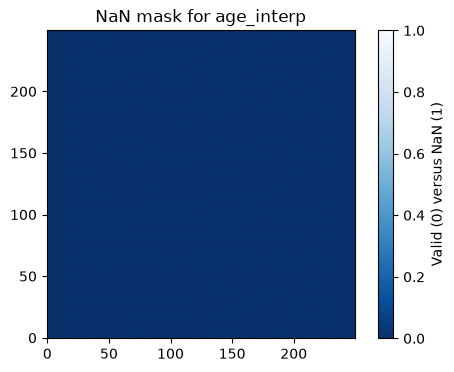

In [356]:
np.where(np.isnan(lola))

plt.figure(figsize=(6,4))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [357]:
lola_pred = model.predict(lola)

In [358]:
lola_pred[180:184]

array([ 2.00375385, -2.16224975,  9.26659443, 17.75030217])

In [359]:
lola_pred = lola_pred.reshape(long.shape)

In [360]:
lola_pred.shape

(250, 250)

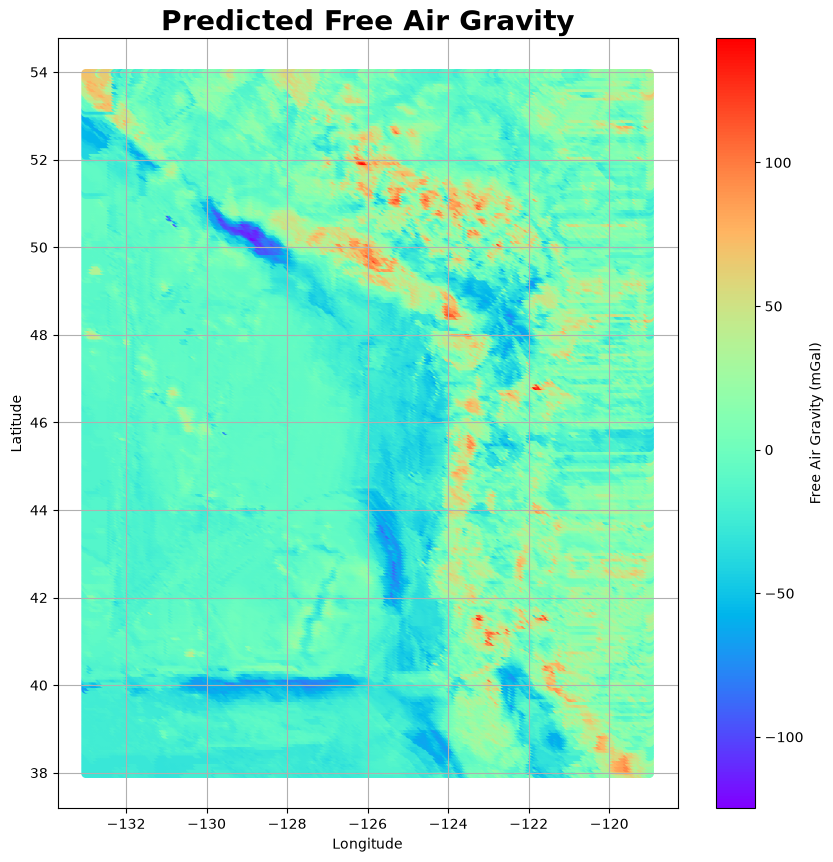

In [361]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\aug17_NOlola_grav_pred_{sp}.png', dpi=400)
plt.show()

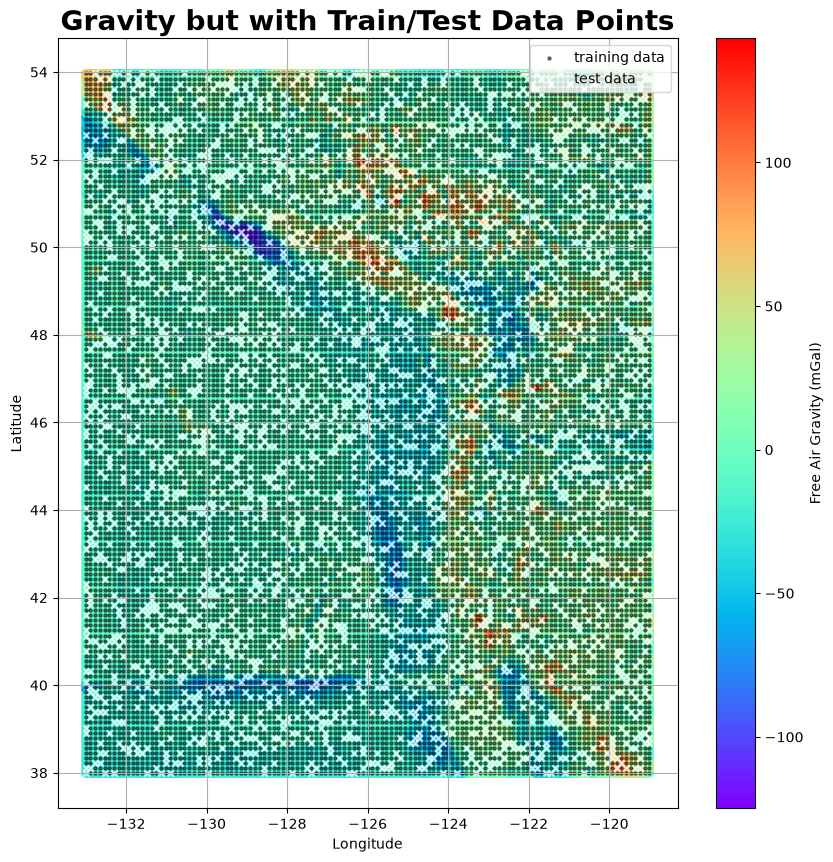

In [362]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(coords_train['long'], coords_train['lat'], marker='o', color='black', s=5, label='training data', alpha=0.5)
plt.scatter(coords_test['long'], coords_test['lat'], marker='x', color='white', s=20, label='test data', alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\aug17_NOlola_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()

## now the predicton will be from a specified area...

In [ ]:
sp = 250

long_min = -132
long_max = -129
lat_min = 45
lat_max = 47

grid_long = np.linspace(long_min, long_max, sp)
grid_lat = np.linspace(lat_min, lat_max, sp)

In [ ]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [ ]:
long.shape, lat.shape

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(long, lat, marker='^', markersize=5, color='blue', linestyle='none')
plt.show()

In [ ]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [ ]:
np.where(~np.isnan(age_interp))

In [ ]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135]

In [ ]:
age_interp.shape

In [ ]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T
# lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel()]).T

In [ ]:
lola.shape

In [ ]:
np.where(np.isnan(lola))

plt.figure(figsize=(4,4))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [ ]:
lola_pred = model.predict(lola)

In [ ]:
lola_pred[180:184]

In [ ]:
lola_pred = lola_pred.reshape(long.shape)

In [ ]:
lola_pred.shape

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\aug17small_grav_pred_{sp}.png', dpi=400)
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=10, label='training data', alpha=0.5)
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='white', s=25, label='test data', alpha=0.7)
plt.xlim(long_min, long_max)
plt.ylim(lat_min, lat_max)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\aug17small_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()